# Speech Emotion Recognition — Data Processing & Feature Extraction

**Project:** Audio-Based Speaking Feedback System using Emotion Recognition and Acoustic Stress Indicators  
**Datasets:** RAVDESS, CREMA-D, TESS  
**Common labels:** `neutral`, `happy`, `sad`, `angry`, `fear`, `disgust`

Notebook này xử lý đầy đủ phần **Speech Data and Feature Extraction (Rubric 2.1–2.5)**:

1. Tổng quan và cấu trúc dataset.
2. Parse nhãn và chuẩn hóa metadata.
3. Kiểm tra dữ liệu, tiền xử lý, chia tập không rò rỉ speaker.
4. Trích xuất waveform, log-Mel, MFCC, pitch/F0, RMS, ZCR và pause ratio.
5. Minh họa, phân tích và xuất artifact sẵn sàng cho modeling.

> Các chỉ số acoustic chỉ phục vụ phản hồi luyện nói, **không dùng để chẩn đoán stress y tế**.

## 0. Cách sử dụng

- Có thể chạy trên Google Colab hoặc máy local.
- Đặt ba dataset trong `DATA_ROOT`, hoặc chỉnh riêng ba đường dẫn trong cell cấu hình.
- Notebook tự nhận diện các file `.wav`, parse nhãn theo quy tắc tên file của từng dataset.
- Nếu chỉ muốn chạy thử nhanh, đặt `QUICK_RUN = True`.

Cấu trúc thư mục gợi ý:

```text
datasets/
├── RAVDESS/
├── CREMA-D/
└── TESS/
```

In [1]:
# Chạy cell này trên Colab nếu thiếu thư viện.
import sys, subprocess, importlib.util

required = {
    "librosa": "librosa>=0.10.1",
    "soundfile": "soundfile",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing = [pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencies ready.")

Dependencies ready.


In [2]:
from pathlib import Path
import json, re, warnings, hashlib
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("librosa:", librosa.__version__)

librosa: 0.11.0


## 1. Cấu hình

Tất cả audio được chuẩn hóa thành mono, 16 kHz. Độ dài cố định 4 giây được dùng cho feature của mô hình; audio đầy đủ vẫn được dùng để tính các acoustic speaking indicators.

In [3]:
from pathlib import Path

# Kaggle input dataset của bạn
DATA_ROOT = Path("/kaggle/input/datasets/quanghuy225/tripe-dataset")

# Nơi Kaggle cho phép ghi output
PROJECT_ROOT = Path("/kaggle/working/Speech_Project")
OUTPUT_DIR = PROJECT_ROOT / "ser_processed"

RAVDESS_DIRS = [DATA_ROOT / "RAVDESS"]
CREMAD_DIRS = [DATA_ROOT / "CREMA-D"]
TESS_DIRS = [DATA_ROOT / "TESS"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "audio_16k").mkdir(exist_ok=True)

TARGET_SR = 16_000
TARGET_DURATION = 4.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]

QUICK_RUN = False
QUICK_RUN_FILES = 300
CACHE_PREPROCESSED_AUDIO = True

# Nếu chỉ train baseline MFCC + SVM/RF: để False.
# Nếu muốn xuất log-Mel cho CNN: đổi thành True.
SAVE_LOG_MEL = False

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("DATA_ROOT:", DATA_ROOT.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

print("RAVDESS exists:", RAVDESS_DIRS[0].exists())
print("CREMA-D exists:", CREMAD_DIRS[0].exists())
print("TESS exists:", TESS_DIRS[0].exists())

PROJECT_ROOT: /kaggle/working/Speech_Project
DATA_ROOT: /kaggle/input/datasets/quanghuy225/tripe-dataset
OUTPUT_DIR: /kaggle/working/Speech_Project/ser_processed
RAVDESS exists: True
CREMA-D exists: True
TESS exists: True


In [4]:
# Optional Google Drive mount. This cell is skipped automatically outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not running in Colab; using local project paths.")


Not running in Colab; using local project paths.


## 2. Dataset overview và label mapping — Rubric 2.1, 2.2

- **RAVDESS:** tên file mã hóa emotion và actor, ví dụ `03-01-05-01-02-01-12.wav`.
- **CREMA-D:** tên file mã hóa speaker và emotion, ví dụ `1001_DFA_ANG_XX.wav`.
- **TESS:** emotion thường nằm ở cuối tên file hoặc tên thư mục, ví dụ `OAF_back_angry.wav`.

Ta ánh xạ về 6 lớp chung để bảo đảm cả ba dataset đều đóng góp cho mọi nhãn.

In [5]:
from pathlib import Path
import re
import pandas as pd

RAVDESS_EMOTION = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fear", "07": "disgust", "08": "surprise",
}
CREMAD_EMOTION = {
    "NEU": "neutral", "HAP": "happy", "SAD": "sad",
    "ANG": "angry", "FEA": "fear", "DIS": "disgust",
}
TESS_EMOTION = {
    "neutral": "neutral", "happy": "happy", "sad": "sad",
    "angry": "angry", "fear": "fear", "fearful": "fear",
    "disgust": "disgust", "disgusted": "disgust", "pleasant_surprise": "surprise",
    "surprise": "surprise",
}

AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3"}

def audio_files(root):
    """Return audio files while ignoring nested duplicate copies from extracted datasets."""
    if not root.exists():
        return []
    files = sorted(
        (p for p in root.rglob("*") if p.suffix.lower() in AUDIO_EXTENSIONS),
        key=lambda p: (len(p.relative_to(root).parts), str(p).lower()),
    )
    unique = {}
    duplicates = []
    for path in files:
        key = path.name.lower()
        if key in unique:
            duplicates.append(path)
            continue
        unique[key] = path
    if duplicates:
        print(f"[Dedup] {root.name}: ignored {len(duplicates):,} duplicate nested files; kept {len(unique):,} unique files.")
    return list(unique.values())

def parse_ravdess(path):
    parts = path.stem.split("-")
    if len(parts) < 7:
        return None
    emotion = RAVDESS_EMOTION.get(parts[2])
    actor = parts[6]
    return dict(dataset="RAVDESS", speaker_id=f"ravdess_{actor}", emotion=emotion,
                original_emotion=parts[2], gender="male" if int(actor) % 2 else "female")

def parse_cremad(path):
    parts = path.stem.split("_")
    if len(parts) < 3:
        return None
    return dict(dataset="CREMA-D", speaker_id=f"cremad_{parts[0]}",
                emotion=CREMAD_EMOTION.get(parts[2].upper()),
                original_emotion=parts[2], gender="unknown")

def parse_tess(path):
    stem = path.stem.lower().replace("ps", "pleasant_surprise")
    candidates = [k for k in TESS_EMOTION if stem.endswith("_" + k) or k in path.parent.name.lower()]
    if not candidates:
        return None
    original = max(candidates, key=len)
    actor_match = re.match(r"(oaf|yaf)", stem)
    actor = actor_match.group(1) if actor_match else path.parent.name.lower().split("_")[0]
    return dict(dataset="TESS", speaker_id=f"tess_{actor}",
                emotion=TESS_EMOTION[original], original_emotion=original, gender="female")

def build_metadata():
    rows = []
    dataset_configs = [
        (RAVDESS_DIRS, parse_ravdess),
        (CREMAD_DIRS, parse_cremad),
        (TESS_DIRS, parse_tess),
    ]

    for dirs_list, parser in dataset_configs:
        for root in dirs_list:
            files = audio_files(root)
            if QUICK_RUN:
                files = files[:QUICK_RUN_FILES]
            for path in files:
                parsed = parser(path)
                if parsed:
                    rows.append({"filepath": str(path.resolve()), **parsed})
    return pd.DataFrame(rows)

metadata = build_metadata()
if metadata.empty:
    raise FileNotFoundError(
        "Không tìm thấy audio. Hãy chỉnh RAVDESS_DIR, CREMAD_DIR và TESS_DIR trong cell cấu hình."
    )

metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].reset_index(drop=True)
metadata.insert(0, "sample_id", [f"s{i:06d}" for i in range(len(metadata))])
metadata["source_filename"] = metadata["filepath"].apply(lambda x: Path(x).name.lower())
print(f"Parsed {len(metadata):,} unique audio files after filtering to common emotions.")
print("Duplicate dataset+filename in metadata:", metadata.duplicated(["dataset", "source_filename"]).sum())
metadata.head()


[Dedup] RAVDESS: ignored 1,440 duplicate nested files; kept 1,440 unique files.
[Dedup] TESS: ignored 2,800 duplicate nested files; kept 2,800 unique files.
Parsed 10,898 unique audio files after filtering to common emotions.
Duplicate dataset+filename in metadata: 0


,sample_id,filepath,dataset,speaker_id,emotion,original_emotion,gender,source_filename
0,s000000,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-01-01.wav
1,s000001,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-01-02-01.wav
2,s000002,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-01-01.wav
3,s000003,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,neutral,01,male,03-01-01-01-02-02-01.wav
4,s000004,/kaggle/input/datasets/quanghuy225/tripe-datas...,RAVDESS,ravdess_01,happy,03,male,03-01-03-01-01-01-01.wav


## 3. Kiểm tra chất lượng và bổ sung thuộc tính audio

Cell sau kiểm tra file đọc được, sample rate, độ dài, số kênh, biên độ và phát hiện file quá ngắn/rỗng. Các file lỗi sẽ bị loại nhưng vẫn được lưu trong báo cáo validation.

In [6]:
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm.auto import tqdm
from pathlib import Path

# Đảm bảo OUTPUT_DIR đã được định nghĩa
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def inspect_audio(row):
    result = {
        "sample_id": row.sample_id, "readable": False, "error": "",
        "sample_rate": np.nan, "duration": np.nan, "channels": np.nan,
        "peak": np.nan, "rms_raw": np.nan,
    }
    try:
        info = sf.info(row.filepath)
        y, sr = librosa.load(row.filepath, sr=None, mono=True, duration=30)
        result.update(
            readable=len(y) > 0,
            sample_rate=int(info.samplerate),
            duration=float(info.duration),
            channels=int(info.channels),
            peak=float(np.max(np.abs(y))) if len(y) else 0.0,
            rms_raw=float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0,
        )
    except Exception as exc:
        result["error"] = str(exc)
    return result

validation = pd.DataFrame(
    [inspect_audio(r) for r in tqdm(metadata.itertuples(index=False), total=len(metadata))]
)
metadata = metadata.merge(validation.drop(columns="error"), on="sample_id", how="left")
validation.to_csv(OUTPUT_DIR / "audio_validation_report.csv", index=False)

invalid = (~metadata["readable"]) | (metadata["duration"] < 0.25) | (metadata["peak"] == 0)
print("Invalid/too-short/silent files:", int(invalid.sum()))
metadata = metadata.loc[~invalid].reset_index(drop=True)
metadata.describe(include="all").T


  0%|          | 0/10898 [00:00<?, ?it/s]

Invalid/too-short/silent files: 1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sample_id,10897,10897,s000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filepath,10897,10897,/kaggle/input/datasets/quanghuy225/tripe-datas...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,10897,3,CREMA-D,7441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speaker_id,10897,117,tess_yaf,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emotion,10897,6,happy,1863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_emotion,10897,18,FEA,1271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10897,3,unknown,7441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_filename,10897,10897,03-01-01-01-01-01-01.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
readable,10897,1,True,10897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_rate,10897.0,NaN,NaN,NaN,20960.740204,9529.20052,16000.0,16000.0,16000.0,24414.0,96000.0


## 4. EDA — cấu trúc và phân bố dataset

Các biểu đồ dưới đây đáp ứng yêu cầu mô tả số mẫu, nhãn, format, nhóm speech, speaker và các thuộc tính liên quan.

,samples,speakers,mean_duration_s,total_hours
dataset,,,,
CREMA-D,7441,91,2.54,5.26
RAVDESS,1056,24,3.72,1.09
TESS,2400,2,2.06,1.38


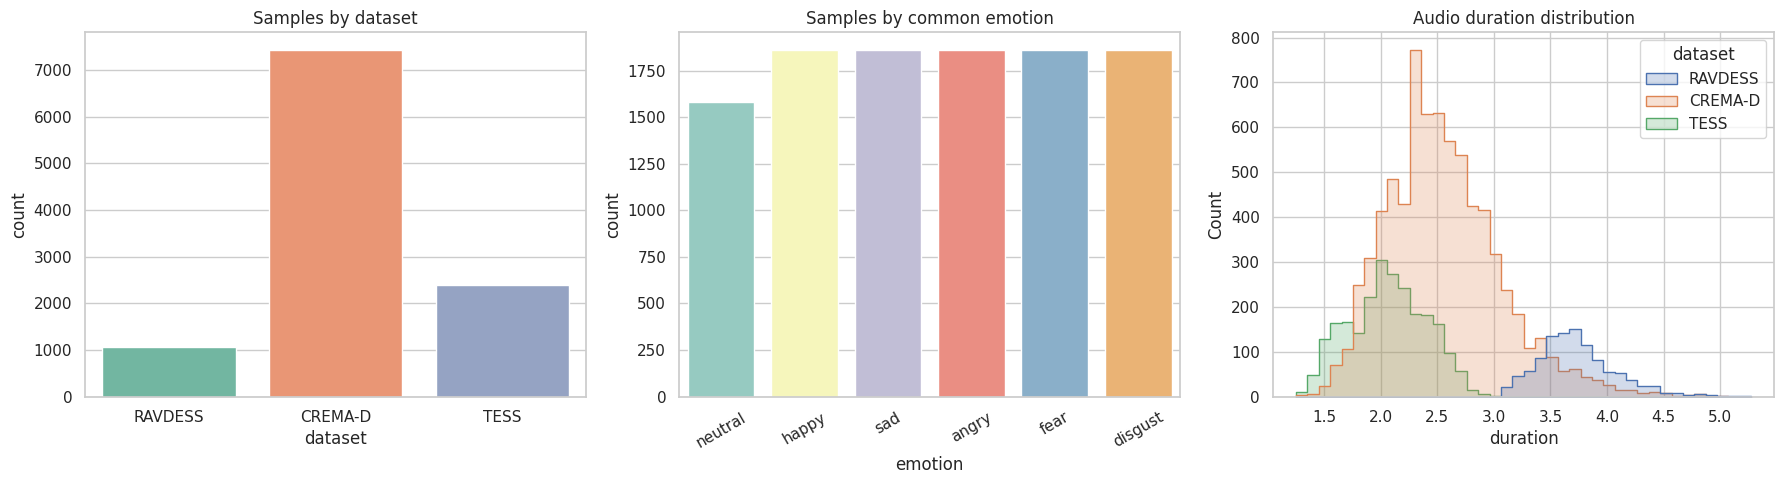

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đảm bảo các cấu hình hiển thị được thiết lập
sns.set_theme(style="whitegrid")

overview = pd.DataFrame({
    "samples": metadata.groupby("dataset").size(),
    "speakers": metadata.groupby("dataset")["speaker_id"].nunique(),
    "mean_duration_s": metadata.groupby("dataset")["duration"].mean(),
    "total_hours": metadata.groupby("dataset")["duration"].sum() / 3600,
}).round(2)
display(overview)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=metadata, x="dataset", ax=axes[0], palette="Set2")
axes[0].set_title("Samples by dataset")

sns.countplot(data=metadata, x="emotion", order=COMMON_EMOTIONS, ax=axes[1], palette="Set3")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("Samples by common emotion")

sns.histplot(data=metadata, x="duration", hue="dataset", bins=40, ax=axes[2], element="step")
axes[2].set_title("Audio duration distribution")
plt.tight_layout()
plt.show()

dataset,CREMA-D,RAVDESS,TESS
emotion,,,
neutral,1087,96,400
happy,1271,192,400
sad,1270,192,400
angry,1271,192,400
fear,1271,192,400
disgust,1271,192,400


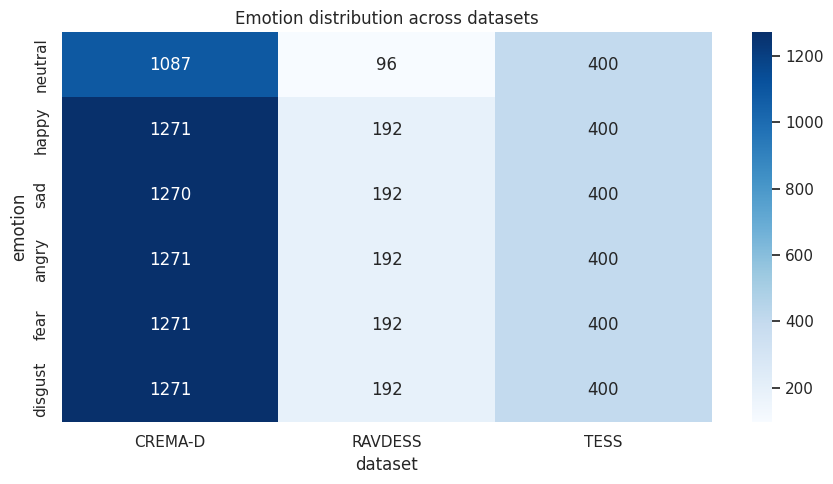

In [8]:
emotion_dataset = pd.crosstab(metadata["emotion"], metadata["dataset"]).reindex(COMMON_EMOTIONS)
display(emotion_dataset)
plt.figure(figsize=(9, 5))
sns.heatmap(emotion_dataset, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion distribution across datasets")
plt.tight_layout()
plt.show()

## 5. Tiền xử lý audio — Rubric 2.3

Quy trình:

1. Đọc mono và resample 16 kHz.
2. Loại DC offset.
3. Trim khoảng lặng đầu/cuối.
4. Peak normalization.
5. Center crop hoặc zero-pad thành 4 giây cho feature mô hình.

Không áp dụng noise reduction mạnh vì có thể làm mất thông tin cảm xúc. Noise augmentation nên chỉ thực hiện trên tập train khi modeling.

In [9]:
import numpy as np
import librosa

# Reuse TARGET_SR/TARGET_DURATION from the configuration cell.
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def preprocess_audio(filepath, fixed_length=True):
    # Load audio với sample rate mục tiêu
    y, _ = librosa.load(filepath, sr=TARGET_SR, mono=True)
    y = y.astype(np.float32)
    y = y - np.mean(y)
    y, _ = librosa.effects.trim(y, top_db=30)

    peak = np.max(np.abs(y)) if len(y) else 0
    if peak > 0:
        y = y / peak

    if fixed_length:
        if len(y) > TARGET_LENGTH:
            start = (len(y) - TARGET_LENGTH) // 2
            y = y[start:start + TARGET_LENGTH]
        else:
            left = (TARGET_LENGTH - len(y)) // 2
            right = TARGET_LENGTH - len(y) - left
            y = np.pad(y, (left, right))
    return y.astype(np.float32)

# Chạy thử nghiệm với mẫu đầu tiên
example = metadata.iloc[0]
y_fixed = preprocess_audio(example.filepath)
print(example[["dataset", "emotion", "filepath"]].to_dict())
print("Processed shape:", y_fixed.shape, "| seconds:", len(y_fixed) / TARGET_SR)


{'dataset': 'RAVDESS', 'emotion': 'neutral', 'filepath': '/kaggle/input/datasets/quanghuy225/tripe-dataset/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav'}
Processed shape: (64000,) | seconds: 4.0


## 6. Speaker-independent train/validation/test split

Ta chia theo `speaker_id`, không chia ngẫu nhiên từng audio. Điều này ngăn cùng một giọng người nói xuất hiện ở cả train và test.

TESS chỉ có hai speaker nên không thể tự phân bố vào đủ ba split. Khi kết hợp ba dataset, split theo speaker toàn cục vẫn ngăn leakage; cần ghi rõ hạn chế này trong báo cáo.

In [10]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Đảm bảo RANDOM_STATE đã được định nghĩa
RANDOM_STATE = 42

def speaker_independent_split(df, test_size=0.20, val_size_from_remaining=0.125):
    groups = df["speaker_id"]
    outer = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
    train_val_idx, test_idx = next(outer.split(df, groups=groups))
    train_val, test = df.iloc[train_val_idx].copy(), df.iloc[test_idx].copy()

    inner = GroupShuffleSplit(n_splits=1, test_size=val_size_from_remaining, random_state=RANDOM_STATE)
    train_idx, val_idx = next(inner.split(train_val, groups=train_val["speaker_id"]))
    train, val = train_val.iloc[train_idx].copy(), train_val.iloc[val_idx].copy()

    train["split"], val["split"], test["split"] = "train", "validation", "test"
    return pd.concat([train, val, test], ignore_index=True)

metadata = speaker_independent_split(metadata)

speaker_sets = {
    split: set(part["speaker_id"])
    for split, part in metadata.groupby("split")
}
assert speaker_sets["train"].isdisjoint(speaker_sets["validation"])
assert speaker_sets["train"].isdisjoint(speaker_sets["test"])
assert speaker_sets["validation"].isdisjoint(speaker_sets["test"])

split_summary = pd.crosstab(metadata["split"], metadata["emotion"]).reindex(
    ["train", "validation", "test"]
)
display(split_summary)
print(metadata.groupby("split").agg(samples=("sample_id", "count"), speakers=("speaker_id", "nunique")))

emotion,angry,disgust,fear,happy,neutral,sad
split,,,,,,
train,1210,1210,1210,1210,1013,1209
validation,162,162,162,162,135,162
test,491,491,491,491,435,491


            samples  speakers
split                        
test           2890        24
train          7062        81
validation      945        12


## 7. Trích xuất feature — Rubric 2.4

### Feature vector cho baseline

- MFCC 40 hệ số cùng delta và delta-delta.
- RMS energy.
- Zero-crossing rate.
- Spectral centroid và bandwidth.
- Pitch/F0 statistics.
- Pause ratio.

Với từng chuỗi feature theo thời gian, lấy mean và standard deviation để tạo vector cố định cho SVM/Random Forest.

In [11]:
def safe_stats(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return (float(np.mean(x)), float(np.std(x))) if len(x) else (0.0, 0.0)

def acoustic_indicators(y, sr=TARGET_SR):
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    intervals = librosa.effects.split(y, top_db=30)
    speech_samples = sum(end - start for start, end in intervals)
    pause_ratio = 1 - speech_samples / max(len(y), 1)

    f0, voiced_flag, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"), sr=sr
    )
    voiced_f0 = f0[np.isfinite(f0)] if f0 is not None else np.array([])
    pitch_mean, pitch_std = safe_stats(voiced_f0)
    rms_mean, rms_std = safe_stats(rms)
    zcr_mean, zcr_std = safe_stats(zcr)
    return {
        "pitch_mean": pitch_mean, "pitch_std": pitch_std,
        "rms_mean": rms_mean, "rms_std": rms_std,
        "zcr_mean": zcr_mean, "zcr_std": zcr_std,
        "pause_ratio": float(pause_ratio),
        "voiced_ratio": float(np.mean(voiced_flag)) if voiced_flag is not None else 0.0,
    }

def summarize_matrix(feature):
    return np.concatenate([np.mean(feature, axis=1), np.std(feature, axis=1)])

def extract_baseline_features(filepath):
    y = preprocess_audio(filepath, fixed_length=True)
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=40, n_fft=1024, hop_length=256)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR)
    vector = np.concatenate([
        summarize_matrix(x) for x in [mfcc, delta, delta2, rms, zcr, centroid, bandwidth]
    ]).astype(np.float32)
    return vector

def extract_log_mel(filepath):
    y = preprocess_audio(filepath, fixed_length=True)
    mel = librosa.feature.melspectrogram(
        y=y, sr=TARGET_SR, n_fft=1024, hop_length=256, n_mels=128, fmax=8000
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

test_vector = extract_baseline_features(metadata.iloc[0].filepath)
test_mel = extract_log_mel(metadata.iloc[0].filepath)
print("Baseline vector shape:", test_vector.shape)
print("Log-Mel shape:", test_mel.shape)

Baseline vector shape: (248,)
Log-Mel shape: (128, 251)


## 8. Minh họa waveform, spectrogram, MFCC và log-Mel — Rubric 2.5

Chọn một mẫu đại diện cho mỗi cảm xúc. Các hình này có thể sử dụng trực tiếp trong báo cáo, kèm nhận xét thận trọng về xu hướng năng lượng, pitch và phân bố phổ.

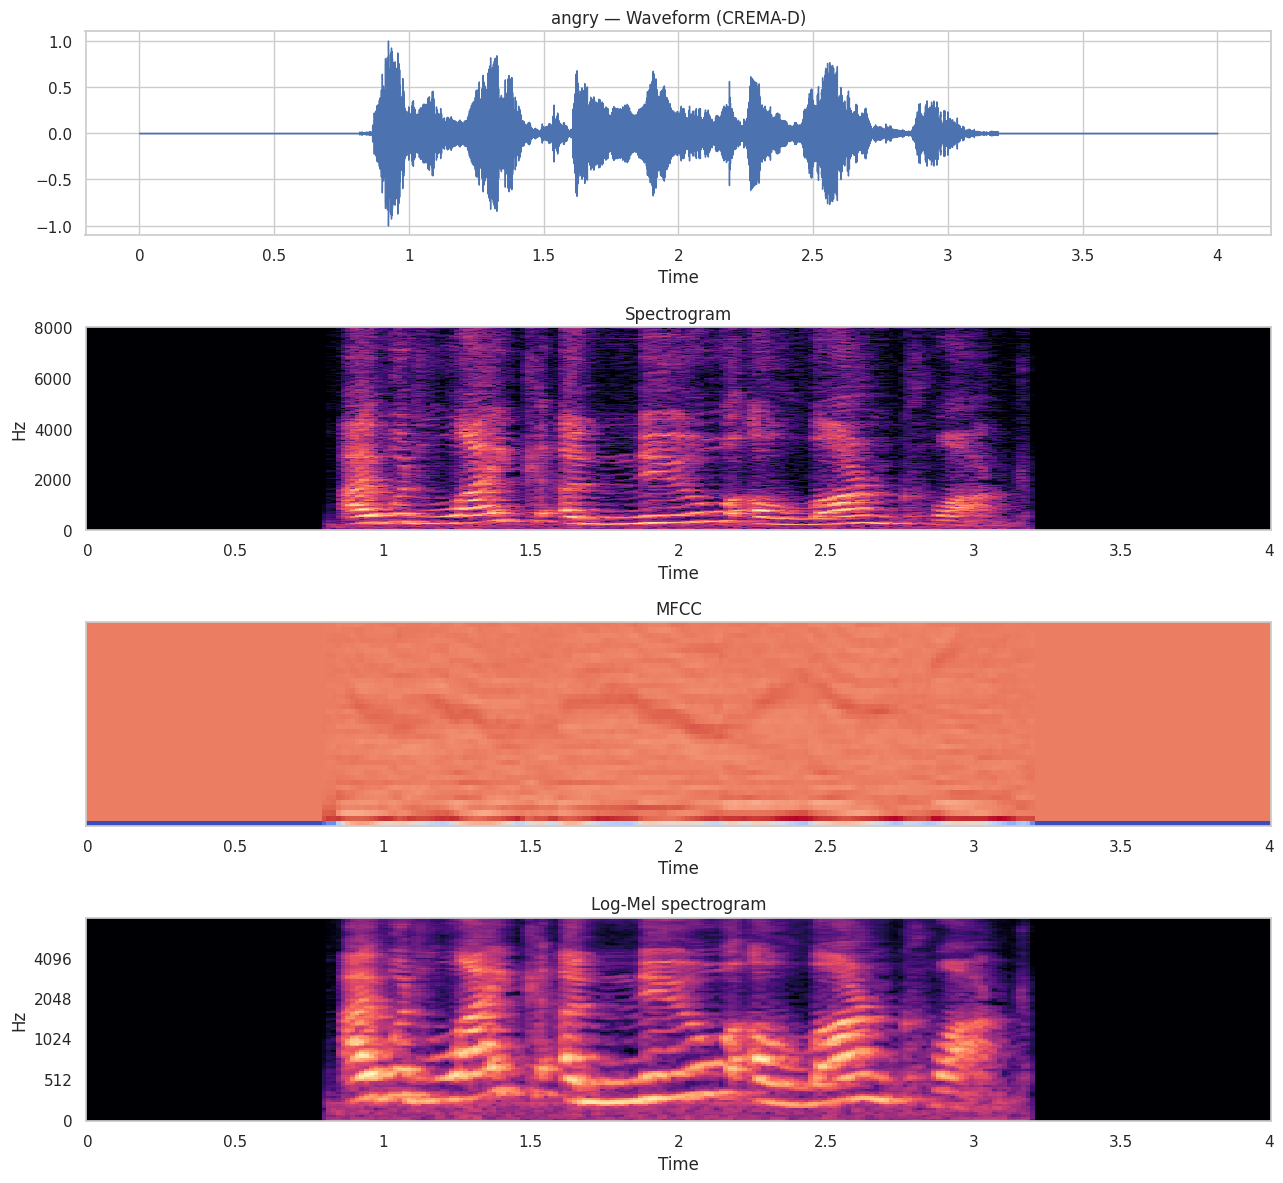

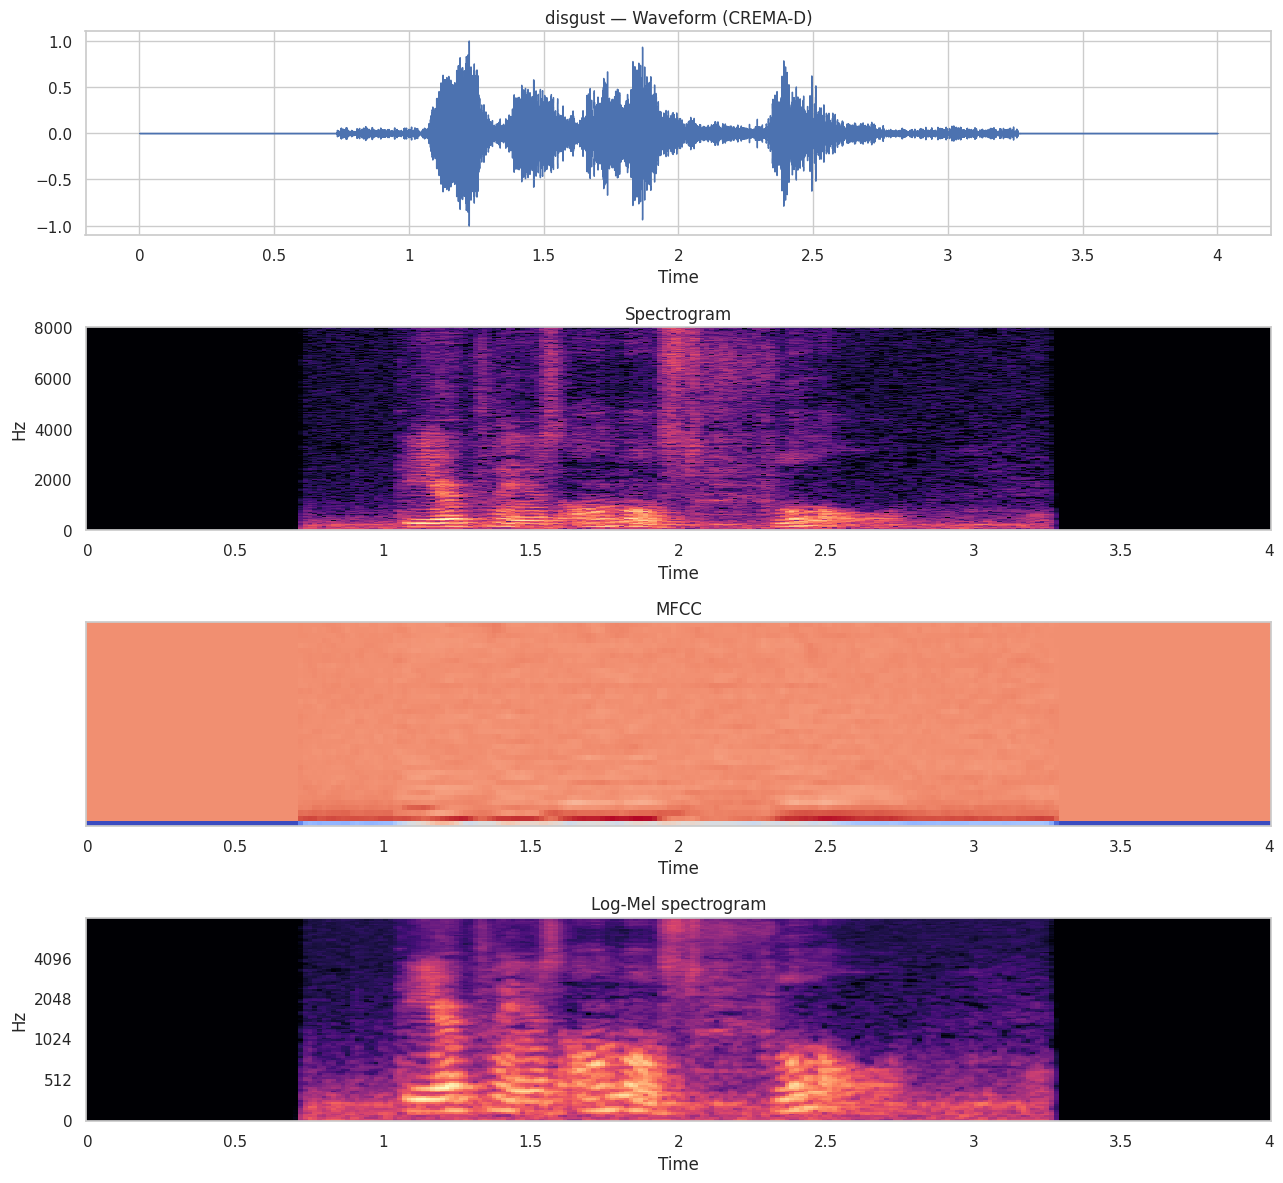

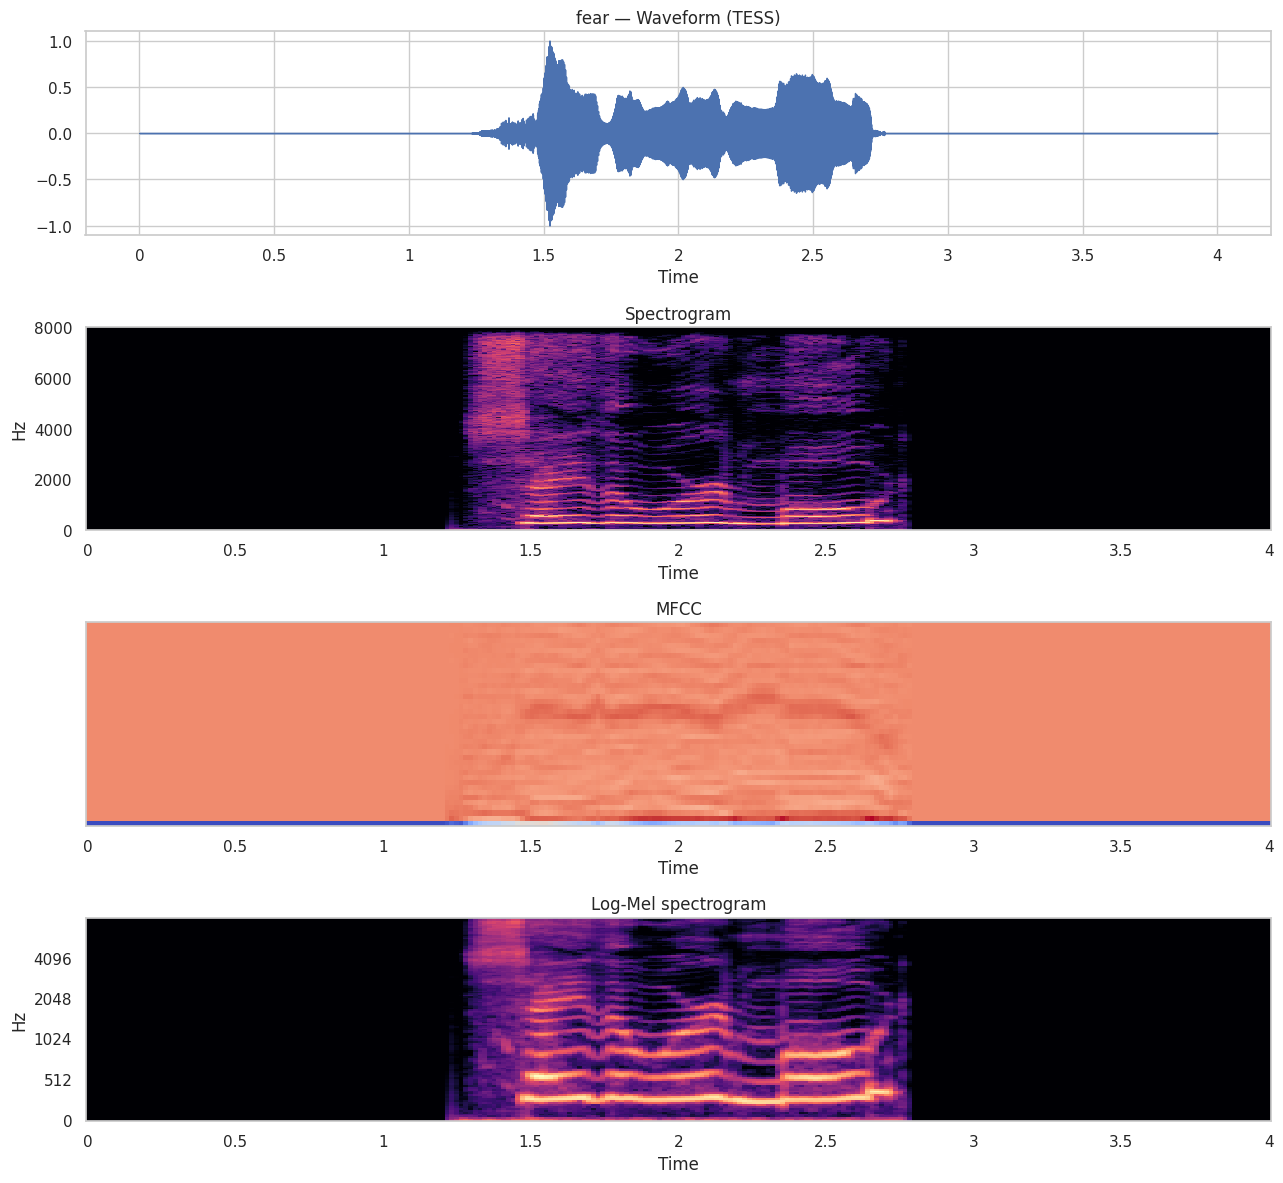

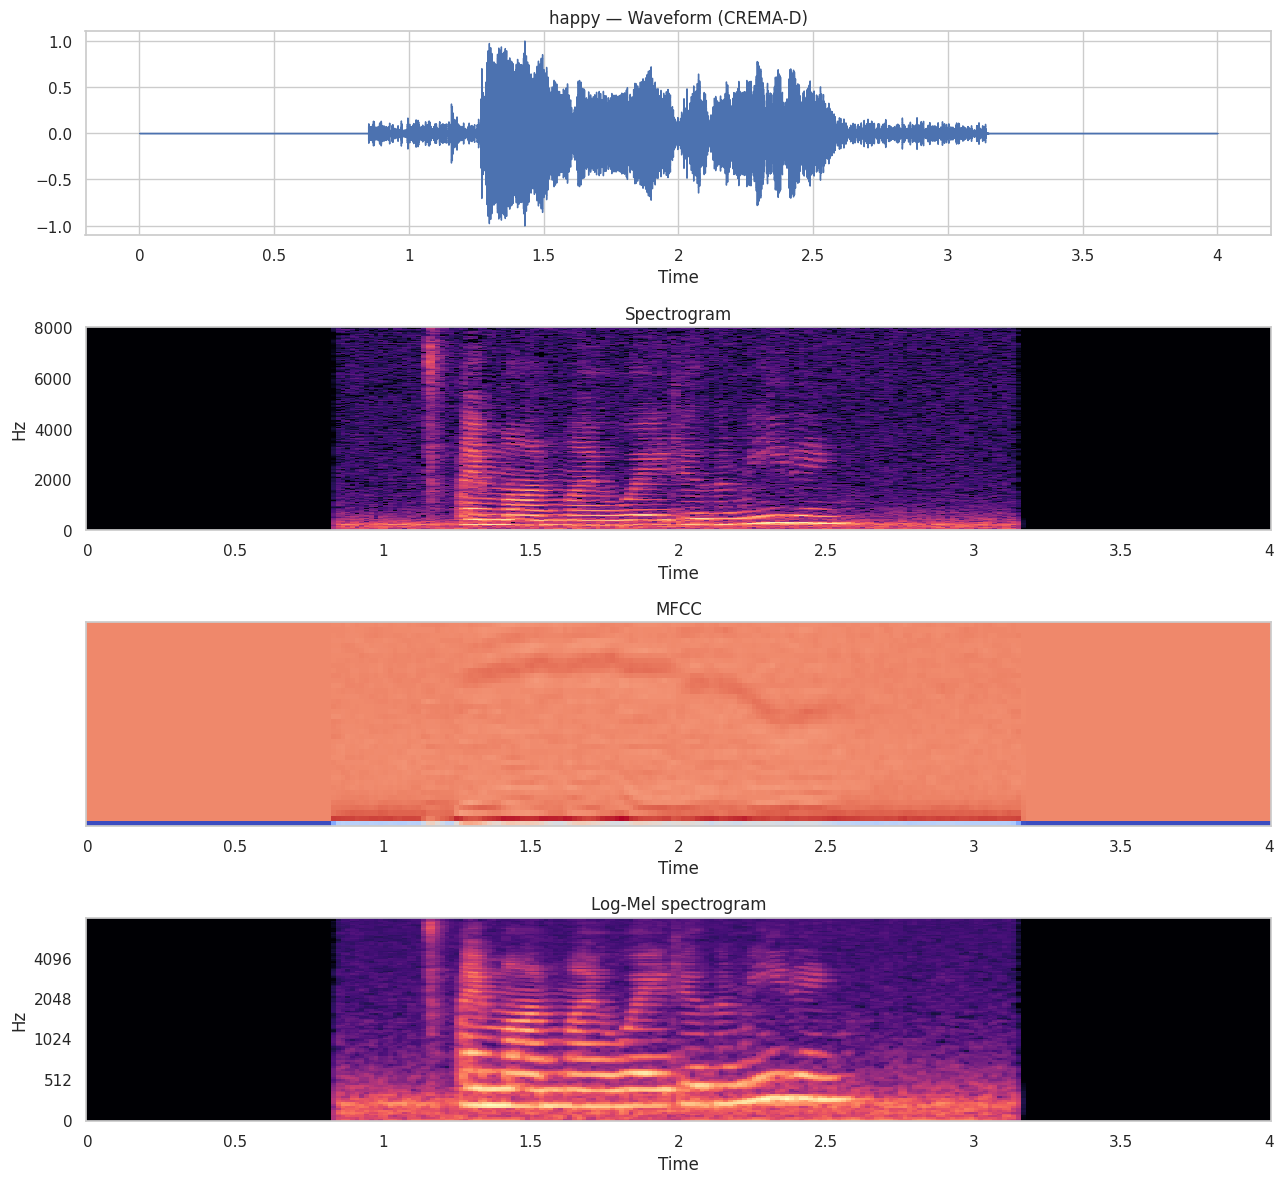

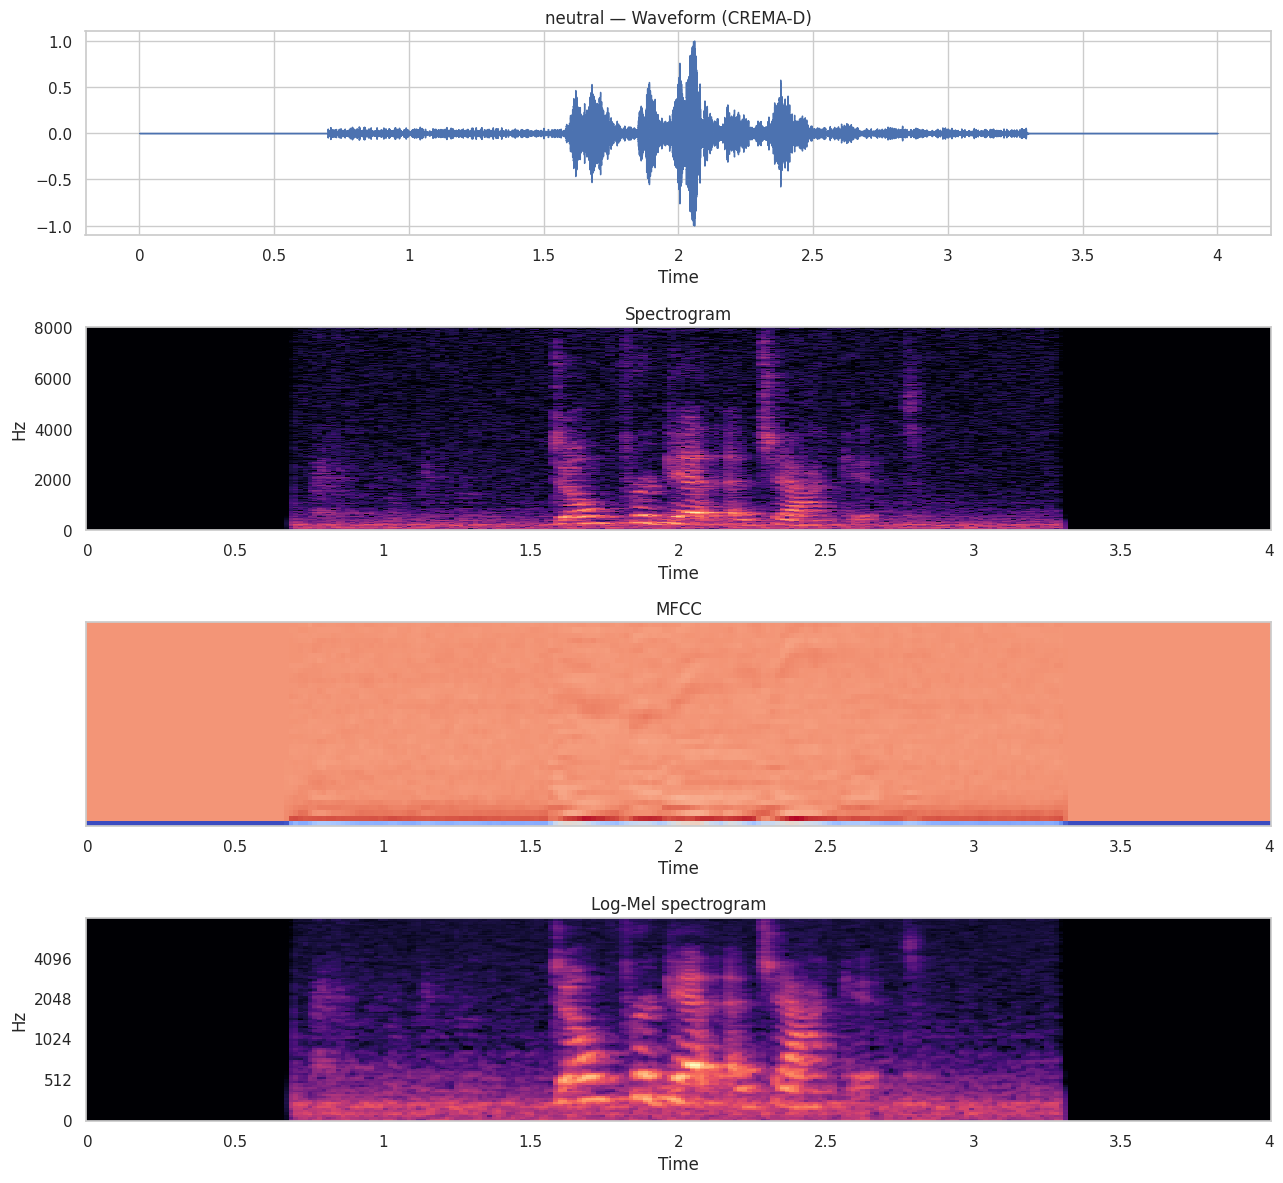

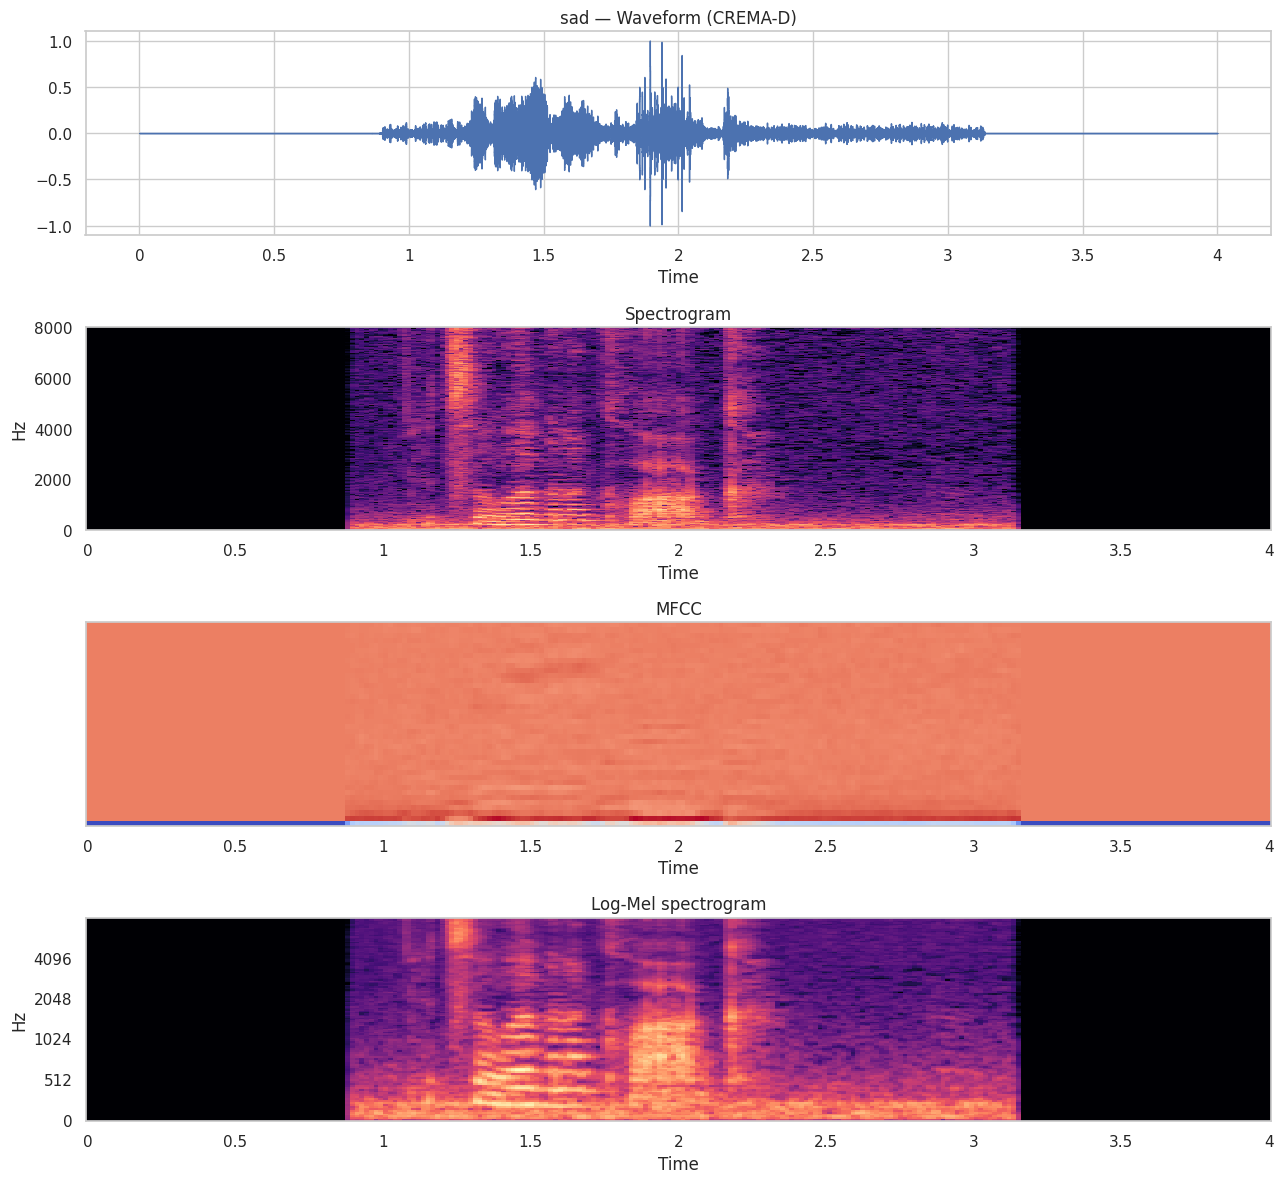

In [12]:
examples = metadata.groupby("emotion", group_keys=False).sample(1, random_state=RANDOM_STATE)

for row in examples.itertuples(index=False):
    y = preprocess_audio(row.filepath, fixed_length=True)
    stft_db = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=1024, hop_length=256)), ref=np.max)
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=40, n_fft=1024, hop_length=256)
    mel_db = extract_log_mel(row.filepath)

    fig, axes = plt.subplots(4, 1, figsize=(13, 12))
    librosa.display.waveshow(y, sr=TARGET_SR, ax=axes[0])
    axes[0].set_title(f"{row.emotion} — Waveform ({row.dataset})")
    librosa.display.specshow(stft_db, sr=TARGET_SR, hop_length=256, x_axis="time", y_axis="hz", ax=axes[1])
    axes[1].set_title("Spectrogram")
    librosa.display.specshow(mfcc, sr=TARGET_SR, hop_length=256, x_axis="time", ax=axes[2])
    axes[2].set_title("MFCC")
    librosa.display.specshow(mel_db, sr=TARGET_SR, hop_length=256, x_axis="time", y_axis="mel", ax=axes[3])
    axes[3].set_title("Log-Mel spectrogram")
    plt.tight_layout()
    plt.show()

## 9. Phân tích acoustic indicators theo cảm xúc

Các biểu đồ giúp kiểm tra xu hướng, nhưng không được xem các feature này là quy luật tuyệt đối. Emotion, dataset, speaker, câu nói và điều kiện thu đều có thể ảnh hưởng.

Acoustic indicator sample:   0%|          | 0/180 [00:00<?, ?it/s]

,pitch_mean,pitch_std,rms_mean,pause_ratio
emotion,,,,
angry,225.481,41.676,0.117,0.024
disgust,171.912,32.745,0.098,0.021
fear,234.607,40.139,0.119,0.012
happy,198.857,51.065,0.107,0.014
neutral,160.542,26.078,0.120,0.002
sad,167.854,33.889,0.132,0.005


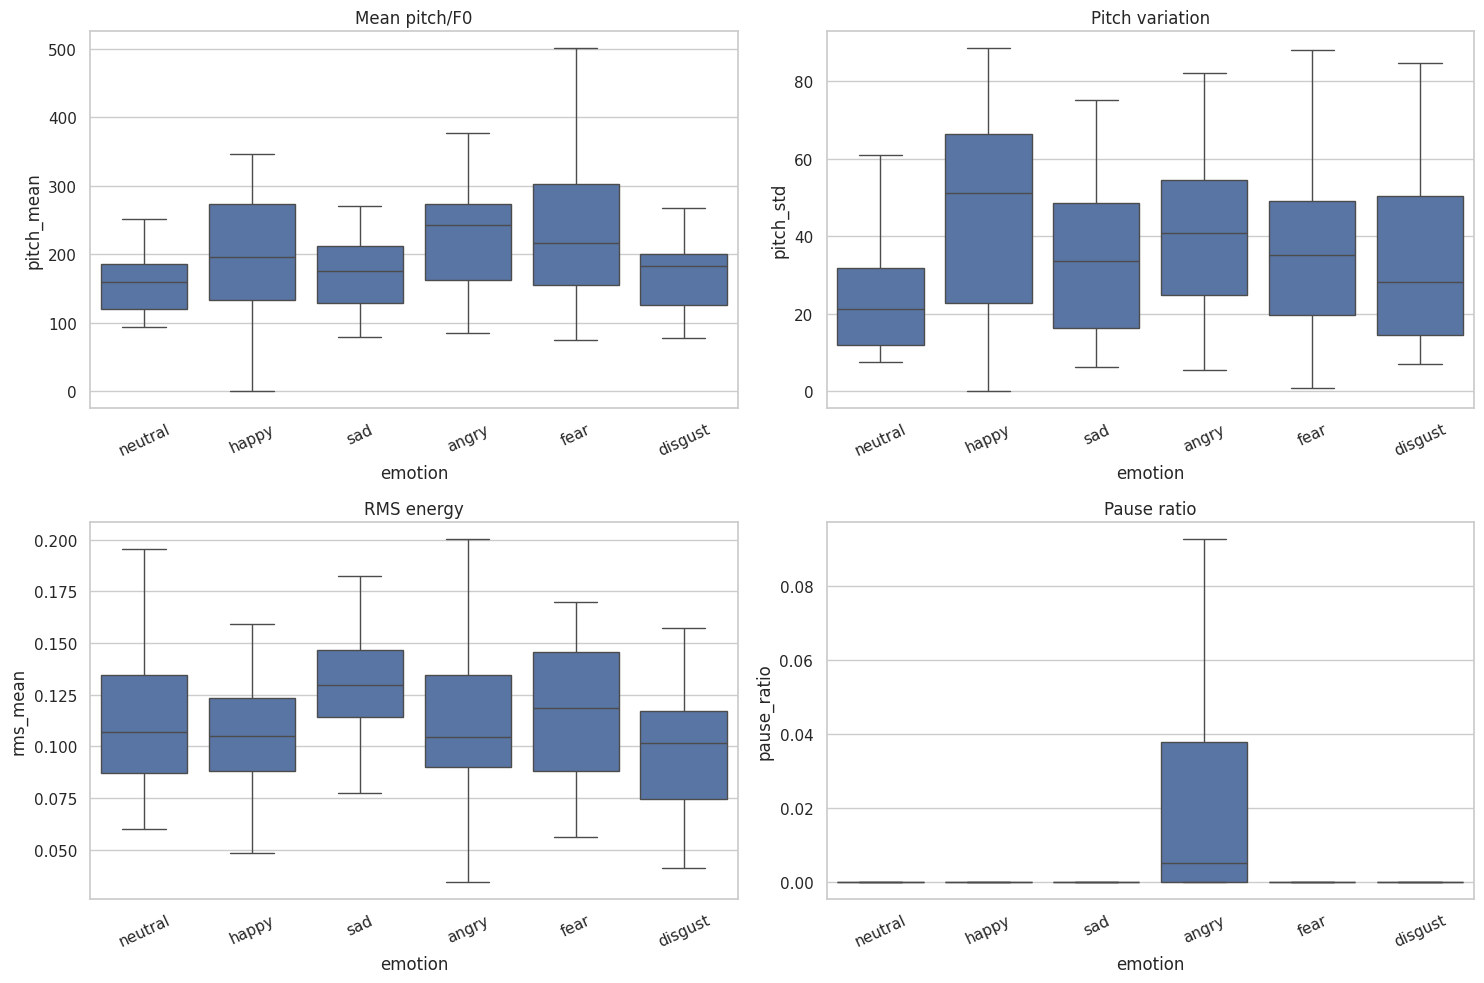

In [13]:
# Keep this sample small enough for CPU-only refresh runs; full EDA can compute a larger sample later.
INDICATOR_SAMPLE_PER_EMOTION = 20 if QUICK_RUN else 30
indicator_source = (
    metadata.groupby("emotion", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), INDICATOR_SAMPLE_PER_EMOTION), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

indicator_rows = []
for row in tqdm(indicator_source.itertuples(index=False), total=len(indicator_source), desc="Acoustic indicator sample"):
    y = preprocess_audio(row.filepath, fixed_length=False)
    indicator_rows.append({
        "sample_id": row.sample_id, "dataset": row.dataset, "emotion": row.emotion,
        **acoustic_indicators(y),
    })
indicators = pd.DataFrame(indicator_rows)
indicators.to_csv(OUTPUT_DIR / "acoustic_indicators_sample.csv", index=False)
display(indicators.groupby("emotion")[["pitch_mean", "pitch_std", "rms_mean", "pause_ratio"]].mean().round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col, title in zip(
    axes.flat,
    ["pitch_mean", "pitch_std", "rms_mean", "pause_ratio"],
    ["Mean pitch/F0", "Pitch variation", "RMS energy", "Pause ratio"],
):
    sns.boxplot(data=indicators, x="emotion", y=col, order=COMMON_EMOTIONS, ax=ax, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 10. Batch extraction và xuất artifact

Cell này có thể tốn thời gian khi chạy toàn bộ dữ liệu. Kết quả:

- `metadata.csv`: metadata và split.
- `baseline_features.npz`: feature vectors và label cho baseline.
- `acoustic_indicators_sample.csv`: indicators dùng cho EDA.
- `processing_config.json`: cấu hình tái lập.

Log-Mel có kích thước lớn, vì vậy cell dưới lưu từng tensor vào thư mục riêng thay vì gom toàn bộ vào RAM.

In [14]:
import numpy as np
import pandas as pd
import soundfile as sf
import json
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Reuse configuration from the setup cell.
audio_out_dir = OUTPUT_DIR / "audio_16k"
audio_out_dir.mkdir(parents=True, exist_ok=True)

feature_vectors, labels, sample_ids, splits = [], [], [], []

for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Baseline features"):
    try:
        # Trích xuất vector đặc trưng
        fv = extract_baseline_features(row.filepath)
        feature_vectors.append(fv)
        labels.append(row.emotion)
        sample_ids.append(row.sample_id)
        splits.append(row.split)

        if CACHE_PREPROCESSED_AUDIO:
            y = preprocess_audio(row.filepath, fixed_length=False)
            # Sử dụng str(path) để tương thích tốt hơn với soundfile
            output_path = str(audio_out_dir / f"{row.sample_id}.wav")
            sf.write(output_path, y, TARGET_SR)
    except Exception as exc:
        print(f"Skipped: {row.sample_id} | {exc}")

if not feature_vectors:
    print("No features extracted. Please check dataset paths.")
else:
    X = np.vstack(feature_vectors)
    y_labels = np.asarray(labels)
    sample_ids_arr = np.asarray(sample_ids)
    splits_arr = np.asarray(splits)

    # Fit scaler chỉ trên train để tránh data leakage
    scaler = StandardScaler()
    train_mask = (splits_arr == "train")
    X_scaled = np.empty_like(X, dtype=np.float32)

    if train_mask.any():
        X_scaled[train_mask] = scaler.fit_transform(X[train_mask]).astype(np.float32)
        if (~train_mask).any():
            X_scaled[~train_mask] = scaler.transform(X[~train_mask]).astype(np.float32)

    # Lưu các artifact
    np.savez_compressed(
        OUTPUT_DIR / "baseline_features.npz",
        X=X, X_scaled=X_scaled, y=y_labels, sample_id=sample_ids_arr, split=splits_arr,
        scaler_mean=scaler.mean_ if hasattr(scaler, 'mean_') else None,
        scaler_scale=scaler.scale_ if hasattr(scaler, 'scale_') else None,
    )
    metadata.to_csv(OUTPUT_DIR / "metadata.csv", index=False)

    config = {
        "target_sample_rate": TARGET_SR,
        "target_duration_seconds": TARGET_DURATION,
        "common_emotions": COMMON_EMOTIONS,
        "split_strategy": "GroupShuffleSplit by speaker_id",
        "random_state": RANDOM_STATE,
        "baseline_feature_dimension": int(X.shape[1]),
    }
    (OUTPUT_DIR / "processing_config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

    print("Saved artifacts to:", OUTPUT_DIR.resolve())
    print(f"X shape: {X.shape} | Labels: {len(y_labels)}")


Baseline features:   0%|          | 0/10897 [00:00<?, ?it/s]

Saved artifacts to: /kaggle/working/Speech_Project/ser_processed
X shape: (10897, 248) | Labels: 10897


In [15]:
# Optional: save log-Mel tensors for CNN training. This can create many files, so it is off by default.
if SAVE_LOG_MEL:
    mel_dir = OUTPUT_DIR / "log_mel"
    mel_dir.mkdir(exist_ok=True)
    for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Log-Mel"):
        np.save(mel_dir / f"{row.sample_id}.npy", extract_log_mel(row.filepath))
    print("Saved Log-Mel tensors:", mel_dir.resolve())
else:
    print("SAVE_LOG_MEL=False; skipped CNN log-Mel export for this baseline data refresh.")


SAVE_LOG_MEL=False; skipped CNN log-Mel export for this baseline data refresh.


## 11. Kiểm tra đầu ra và kết luận

Checklist đáp ứng rubric:

- **2.1:** Trình bày RAVDESS, CREMA-D, TESS và mục đích sử dụng.
- **2.2:** Metadata gồm số mẫu, nhãn, format, speaker, duration, sample rate, gender.
- **2.3:** Mono, resample 16 kHz, trim silence, normalize, pad/crop, label mapping và speaker-independent split.
- **2.4:** Waveform, spectrogram, MFCC, log-Mel, pitch/F0, RMS, ZCR, pause ratio.
- **2.5:** Hình minh họa theo emotion và biểu đồ so sánh acoustic indicators.

### Hạn chế cần ghi trong báo cáo

1. Dataset là acted emotion, có thể khác cảm xúc tự nhiên trong bài nói thực tế.
2. TESS chỉ có hai speaker nữ nên có rủi ro thiên lệch speaker/gender.
3. Ba dataset có điều kiện thu và độ rõ khác nhau, mô hình có thể học dấu hiệu dataset.
4. Acoustic indicators chỉ tạo phản hồi luyện nói, không phải thước đo stress lâm sàng.

In [16]:
print("Final metadata shape:", metadata.shape)
print("Duplicate filepath:", metadata["filepath"].duplicated().sum())
print("Duplicate dataset+source_filename:", metadata.duplicated(["dataset", "source_filename"]).sum())
print("Missing emotion:", metadata["emotion"].isna().sum())
print("Splits:", metadata["split"].value_counts().to_dict())
print("Artifacts:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)


Final metadata shape: (10897, 15)
Duplicate filepath: 0
Duplicate dataset+source_filename: 0
Missing emotion: 0
Splits: {'train': 7062, 'test': 2890, 'validation': 945}
Artifacts:
 - acoustic_indicators_sample.csv
 - audio_16k
 - audio_validation_report.csv
 - baseline_features.npz
 - metadata.csv
 - processing_config.json
